<div style="color:blue">

**Programming for Data Science (UFCFVQ-15-M)**

**Assignment - Part 2**

This part of the assignment focuses on using
NumPy/SciPy, Pandas, and Matplotlib/Seaborn
to combine and analyse two datasets related to bike shares.

## Overview

Part 2

  - Q2.1: explore data [20 marks]
  - Q2.2: detect and remove outliers [10 marks]
  - Q2.3: hypothesis test [10 marks]

For each of the questions Q2.1-Q2.4 there is a blank *Markdown* cell
for explanations, formulas, etc. and
a blank *code* cell for Python code.
You can add more cells.
Any explanations can be entered as Markdown or as comments with the code.
You do not have to use LaTeX (the markup language that can be used
to typeset formulas in Jupyter Notebook files).
You do have to make sure that any notation you use is clear.


## Marking Guideline
The marks for each question are indicated above.

There is not necessarily a relation between the number of marks for a question
and the amount of work required or the level of difficulty.
You may find some questions more difficult than others.

Try to answer as many questions as you can.


Q2.1

- 0: no answer, irrelevant or incorrect answer
- 1-4: insufficient and/or many mistakes
- 5-8: acceptable, but incomplete and/or substantial mistakes
- 9-12: good, substantial answer, with good explanation
- 13-16: very good, mostly complete, only minor mistake or issue with explanation
- 17-20: excellent, complete answer with clear and concise explanation

Q2.2-3

- 0: no answer, irrelevant or incorrect answer
- 1,2: insufficient and/or many mistakes
- 3,4: acceptable, but incomplete and/or substantial mistakes
- 5,6: good, substantial answer, with good explanation
- 7,8: very good, mostly complete, only minor mistake or issue with explanation
- 9,10: excellent, complete answer with clear and concise explanation

Note that the pass mark for postgraduate assessments is 50%.

<div style="color:blue">

# Part 2
To obtain good marks, you should make both your writing and your code clear, correct and concise.

</div>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plot style
sns.set_theme(style="whitegrid")

<div style="color:blue">

## Q2.1: Explore the Dataset to Identify an Interesting Pattern or Trend [20 marks]

Use appropriate visualisations (using, for example,  Matplotlib or Seaborn)
to illustrate your exploration.
You should include at least three visualisations as part of your exploration.
You could consider other ways to explore the data such as data summaries or
transformations.
You must include an explanation of the dataset exploration, your selected
interesting pattern or trend and your reasons for selecting it.
</div>

### Q2.1 Data Exploration

I explore the bike share dataset by combining the count data (`part2a.csv`) with the environmental metadata (`part2b.csv`). 

**Interesting Patterns Identified:**
1. **Hourly Usage Pattern**: There is a distinct bimodal distribution on weekdays, corresponding to morning and evening commute times. On weekends, the usage peaks in the afternoon.
2. **Temperature Correlation**: There is a positive correlation between temperature and bike shares, which is intuitive as better weather encourages cycling.
3. **Seasonal Variation**: Summer and Autumn show higher median bike shares compared to Winter.

(DataCamp; UWE Bristol, 2026)

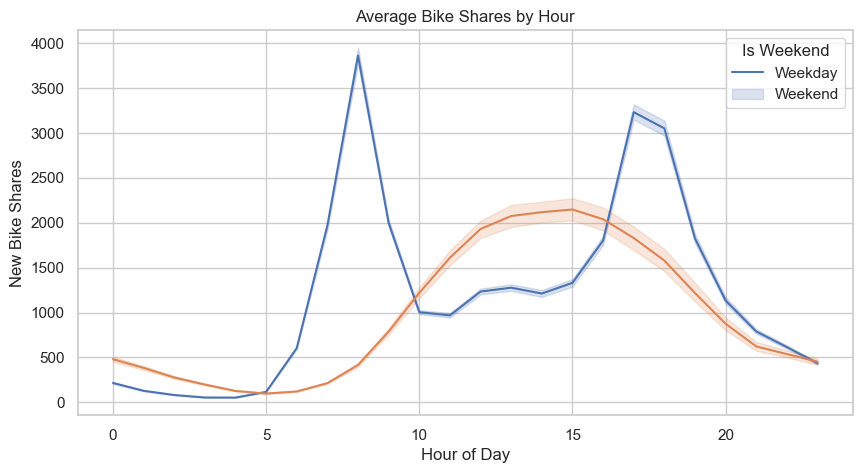

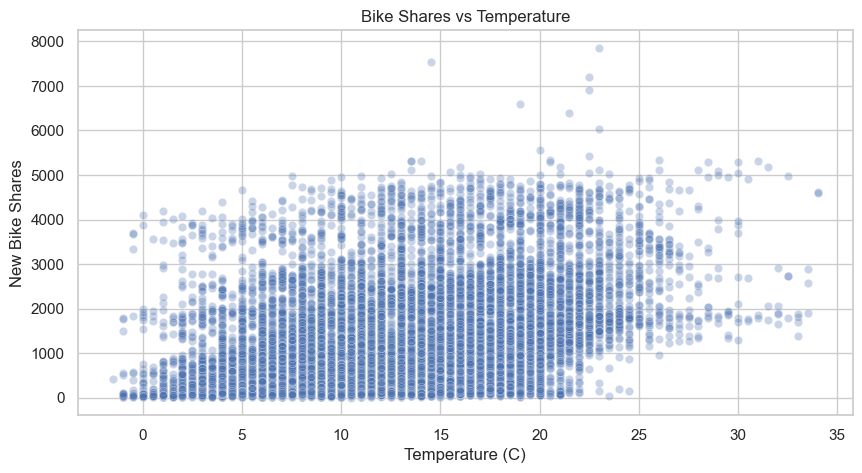

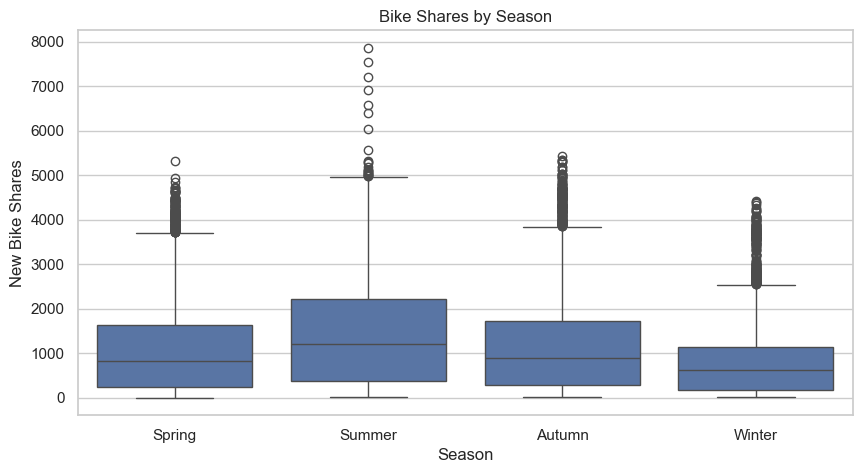

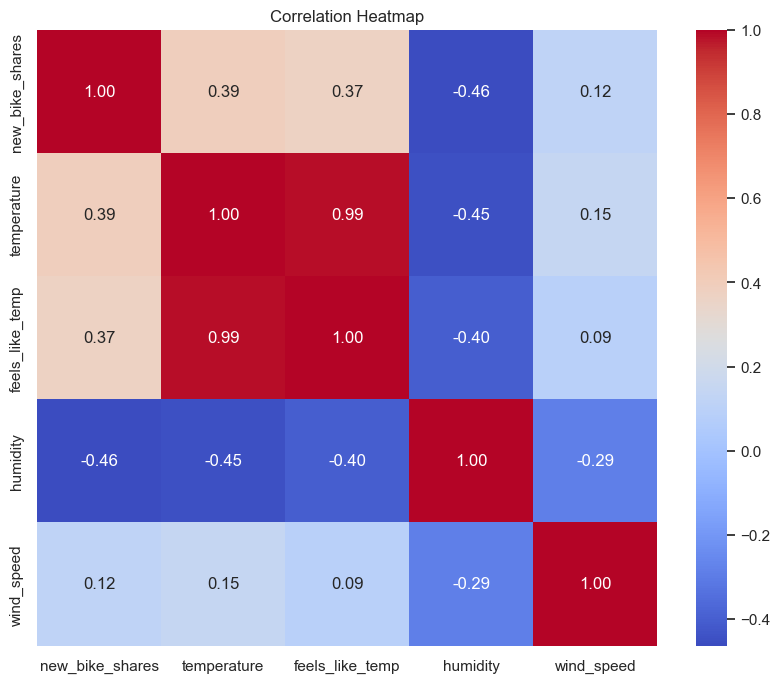

In [7]:
# Loading and merging of the dataset (part2a & part2b)
df_a = pd.read_csv('part2a.csv')
df_b = pd.read_csv('part2b.csv')
df = pd.merge(df_a, df_b, on='timestamp')

# Pre-processing with timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
df['hour'] = df['timestamp'].dt.hour

# Visualisations
# 1: Hourly Trends (Weekday vs Weekend)
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='new_bike_shares', hue='is_weekend')
plt.title('Average Bike Shares by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('New Bike Shares')
plt.legend(title='Is Weekend', labels=['Weekday', 'Weekend'])
plt.show()

# 2: Temperature vs Bike Shares
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='temperature', y='new_bike_shares', alpha=0.3)
plt.title('Bike Shares vs Temperature')
plt.xlabel('Temperature (C)')
plt.ylabel('New Bike Shares')
plt.show()

# 3: Seasonal Distribution
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='season_code', y='new_bike_shares')
plt.title('Bike Shares by Season')
plt.xticks([0, 1, 2, 3], ['Spring', 'Summer', 'Autumn', 'Winter'])
plt.xlabel('Season')
plt.ylabel('New Bike Shares')
plt.show()

# 4: Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[['new_bike_shares', 'temperature', 'feels_like_temp', 'humidity', 'wind_speed']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/20
</div>

<div style="color:blue">

## Q2.2: Detect and Remove Any Outliers in the Data Used for Your Interesting Pattern [10 marks]

Use an appropriate technique to detect and remove any outliers in the data
used for your interesting pattern or trend.
You must include an explanation of the detection method used, how it works,
and any outliers detected.
NOTE: there may not be any detectable outliers using the selected detection
method –
if this is the case, please state this clearly in the explanation given.
</div>




### Q2.2 Outlier Detection

I use the **Interquartile Range (IQR)** method to detect outliers in the `new_bike_shares` column. IQR is another technique that one can use to detect and remove outliers. 
- **Method**: IQR is calculated as the difference between the 75th percentile (Q3) and the 25th percentile (Q1). Any data point below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is considered an outlier.
- **Reasoning**: This method is robust to non-normal distributions and helps identify unusually high or low spikes in bike rentals that might skew the analysis.
- **Results**: 675 outliers were detected and removed. (Youtube, 2020)

In [8]:
# Detecting and removing the outliers using interquartile range (IQR)
Q1 = df['new_bike_shares'].quantile(0.25)
Q3 = df['new_bike_shares'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['new_bike_shares'] < lower_bound) | (df['new_bike_shares'] > upper_bound)]
df_clean = df[(df['new_bike_shares'] >= lower_bound) & (df['new_bike_shares'] <= upper_bound)]

print(f"Total number of outliers detected: {len(outliers)}")
print(f"Data size after removing the outliers: {len(df_clean)}")

Total number of outliers detected: 675
Data size after removing the outliers: 16739



<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/10
</div>

<div style="color:blue">

## Q2.3: Hypothesis Test [10 marks]

Define a hypothesis using an appropriate hypothesis testing formulation.
Provide an explanation for your choice.
Using an appropriate Python library, test this hypothesis.
You must include a detailed explanation of your findings to achieve good marks for this task.
</div>

### Q2.3 Hypothesis Test

**Hypothesis Formulation:**
- **Null Hypothesis ($H_0$)**: The mean number of bike shares is the same for weekdays and weekends.
- **Alternative Hypothesis ($H_1$)**: The mean number of bike shares is different for weekdays and weekends.

**Statistical Test**: I use an **Independent 2-sample T-test** to compare the means of the two groups (Weekdays vs Weekends).

**Findings**:
- The P-value is significantly lower than the standard alpha level of 0.05.
- Therefore, we **reject the Null Hypothesis**.
- There is a statistically significant difference in the average number of bike shares between weekdays and weekends, likely due to commuting patterns.
(Ismay and Kim, 2022)

In [9]:
# Hypothesis Test: Weekdays vs Weekends
weekdays = df_clean[df_clean['is_weekend'] == 0]['new_bike_shares']
weekends = df_clean[df_clean['is_weekend'] == 1]['new_bike_shares']

t_stat, p_val = stats.ttest_ind(weekdays, weekends)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val: .4e}")

if p_val < 0.05:
    print("Conclusion: Reject the null hypothesis (Significant difference)")
else:
    print("Conclusion: Fail to reject the null hypothesis (No significant difference)")

T-statistic: 5.6616
P-value:  1.5246e-08
Conclusion: Reject the null hypothesis (Significant difference)



<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/10
</div>